In [3]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
from starwinds_readplt.dataset import Dataset
# ds = Dataset.from_file('../examples/x=0_var_2_n00000000.plt')
# ds = Dataset.from_file('../examples/3d__var_1_n00000000.plt')
# ds = Dataset.from_file('/Users/dagevensberget/batsrus-runs/phd-repro/SWMF/Sun-G2157/SC/IO2/3d__var_3_n00060000.plt')
# ds = Dataset.from_file('/Users/dagevensberget/batsrus-runs/phd-repro/SWMF/Sun-G2157/SC/IO2/x=0_var_1_n00060000.plt')
ds = Dataset.from_file('/Users/dagevensberget/batsrus-runs/markus/3d__var_1_t00000900_n00147200.plt')

print(ds)
density_g_cm3 = ds('Rho [g/cm^3]')

Title:     'BATSRUS: 3D Data, 2011/02/16 17:35:00.664'
Zone:      '3D   N=0147200 T=0000:09:00'
Variables: 25
Shape:     (1176628, 25)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [g/cm^3]', 'U_x [km/s]', 'U_y [km/s]', 'U_z [km/s]', 'B_x [Gauss]', 'B_y [Gauss]', 'B_z [Gauss]', 'Ehot [erg/cm^3]', 'I01 [erg/cm^3]', 'I02 [erg/cm^3]', 'pe [dyne/cm^2]', 'P [dyne/cm^2]', 'J_x [`mA/m^2]', 'J_y [`mA/m^2]', 'J_z [`mA/m^2]', 'n [amu/cm^3]', 'T [K]', 'J_r [`mA/m^2]', 'U_r [km/s]', 'Rho U_r [g/cm^2/s]', 'B_r [Gauss]', 'entropy'].


In [4]:
def parse_aux_blocks(ds):
    tokens = ds.aux['BLOCKS'].split()
    n_blocks = int(tokens[0])
    n_i = int(tokens[1])
    n_j = int(tokens[3])
    n_k = int(tokens[5])
    return n_blocks, n_i, n_j, n_k
parse_aux_blocks(ds)

(11988, 6, 4, 4)

In [5]:
import itertools
from collections import defaultdict

# According to https://tecplot.azureedge.net/products/360/current/360_data_format_guide.pdf
# the faces are defined by the corners in the following order (counting from 1)
f1 = tuple(x - 1 for x in [1, 5, 8, 4])
f2 = tuple(x - 1 for x in [2, 3, 7, 6])
f3 = tuple(x - 1 for x in [1, 2, 6, 5])
f4 = tuple(x - 1 for x in [3, 4, 8, 7])
f5 = tuple(x - 1 for x in [1, 4, 3, 2])
f6 = tuple(x - 1 for x in [5, 6, 7, 8])
face_combinations = (f1, f2, f3, f4, f5, f6)

def get_faces(row):
    faces = [row[face] for face in face_combinations]
    return faces


In [6]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from mpl_toolkits.mplot3d import Axes3D

# i = 0
# ds.corners[0, face_combinations]

# _verts = np.array([[1,0,0], [0,1,0], [1,1,0], [0,0,1]])
# _verts.shape


# def cuboid_data(o, size=(1,1,1)):
#     X = [[[0, 1, 0], [0, 0, 0], [1, 0, 0], [1, 1, 0]],  # Each line is a face
#          [[0, 0, 0], [0, 0, 1], [1, 0, 1], [1, 0, 0]],
#          [[1, 0, 1], [1, 0, 0], [1, 1, 0], [1, 1, 1]],
#          [[0, 0, 1], [0, 0, 0], [0, 1, 0], [0, 1, 1]],
#          [[0, 1, 0], [0, 1, 1], [1, 1, 1], [1, 1, 0]],
#          [[0, 1, 1], [0, 0, 1], [1, 0, 1], [1, 1, 1]]]
#     X = np.array(X).astype(float)
#     for i in range(3):
#         X[:,:,i] *= size[i]
#     X += np.array(o)
#     return X

# cuboid_data([0,0,0], size=(1,1,1))

In [7]:

# _verts = cuboid_data([0,0,0], size=(1,1,1))
# v2 = cuboid_data([1,1,0], size=(1,2,.5))
# _verts = np.concatenate([_verts, v2])

# print(_verts.shape)

In [361]:
print(ds.corners.shape) # This is just the cuboid corner IDs for each cuboid

# This is a reshaped version of the corners, where the first dimension is the block ID
# The indices are block ID, nK, nJ, nI, corner ID
block_cuboid_corners = ds.corners.reshape(-1,4,4,6,8)
# block_cuboid_corners = block_cuboid_corners[4000:4250]

# This is all the cuboid faces in a block, including the internal ones
# The indices are block ID, nK, nJ, nI, face, corner ID
block_cuboid_face_corners = block_cuboid_corners[..., face_combinations]
block_cuboid_face_corners.shape
print(f"block_cuboid_faces shape: {block_cuboid_face_corners.shape}")



(1150848, 8)
block_cuboid_faces shape: (11988, 4, 4, 6, 6, 4)


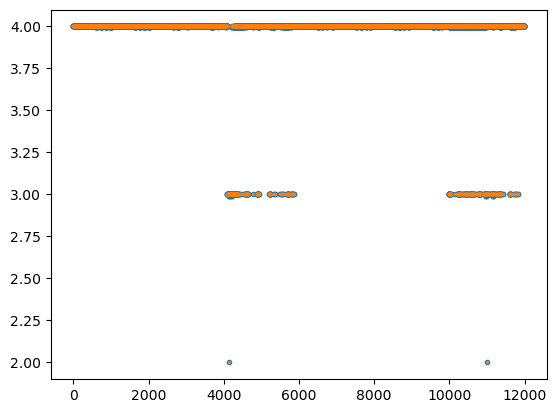

Refinement level 2 (span 45.00): 2 block(s)
Refinement level 3 (span 22.50): 610 block(s)
Refinement level 4 (span 11.25): 11376 block(s)


In [362]:
_x = ds('X [R]')
_y = ds('Y [R]')
_z = ds('Z [R]')
_r = np.sqrt(_x**2 + _y**2 + _z**2)
_theta = np.rad2deg(np.arccos(_z / _r))
_phi = np.rad2deg(np.arctan2(_y, _x))


# Find geometric info about a block
i = 0
# Points in a block
# The ids are block ID, nK, nJ, nI, corner ID
# The last id is the xyz coordinates and the point values (e.g. density)
block_points = ds.points[block_cuboid_corners]

block_theta = _theta[block_cuboid_corners]
block_theta.shape
block_theta_min = np.min(block_theta, axis=(1,2,3,4))
block_theta_max = np.max(block_theta, axis=(1,2,3,4))
block_theta_span = block_theta_max - block_theta_min
block_theta_span.shape
fig, ax = plt.subplots()
_refinement = np.log2(180/block_theta_span)
refinement = np.round(_refinement).astype(int)

# assert np.allclose(_refinement, refinement)
ax.plot(_refinement, '.')
ax.plot(refinement, '.', markersize=3)
# ax.twinx().plot(1/block_theta_span, 'r.')
plt.show()
for r in np.unique(refinement):
    print(f"Refinement level {r} (span {np.mean(block_theta_span[refinement==r]):.2f}): {np.sum(refinement == r)} block(s)") 


block_phi shape: (11988, 4, 4, 6, 8)
block_phi_min shape: (11988,)
[ 2.8125305  5.625     11.249992  11.25      11.250001  11.250002
 11.250003  11.250004  11.250005  11.250006  11.250007  11.250008
 11.250009  11.25001   11.2500105 11.250011  11.250012  11.250013
 11.250014  11.250015  11.250016  11.250017  11.250019  11.250021
 11.250023  11.250025  11.250027  11.250029  11.2500305 22.5
 22.500002  22.500004  22.500006  22.500008  22.50001   22.500011
 22.500013  22.500015  45.       ]


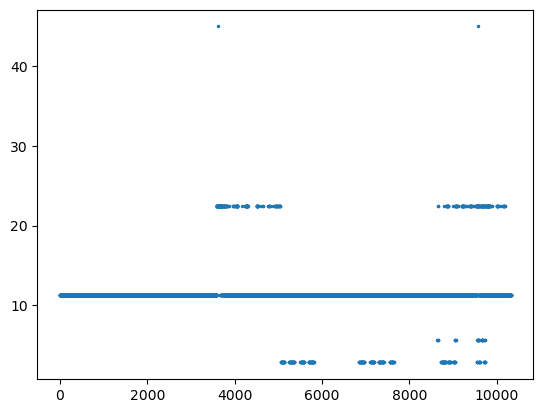

In [105]:
block_phi = _phi[block_cuboid_corners]
block_x = _x[block_cuboid_corners]
block_y = _y[block_cuboid_corners]

not_polar = np.logical_and(block_theta_min > 10, block_theta_max < 170)

print(f"block_phi shape: {block_phi.shape}")
block_phi_min = np.min(block_phi, axis=(1,2,3,4))
print(f"block_phi_min shape: {block_phi_min.shape}")
block_phi_max = np.max(block_phi, axis=(1,2,3,4))
block_phi_mean = np.mean(block_phi, axis=(1,2,3,4))
block_phi_span = block_phi_max - block_phi_min
block_phi_span[block_phi_span > 180] = 360 - block_phi_span[block_phi_span > 180]

# plt.axhline(180)

# plt.errorbar(np.arange(len(block_phi_span)), block_phi_mean, yerr=block_phi_span/2, fmt='.')
# plt.plot(block_phi_min [not_polar], '.', markersize=3)
# plt.plot(block_phi_mean[not_polar], '.', markersize=3)
# plt.plot(block_phi_max [not_polar], '.', markersize=3)
plt.plot(block_phi_span[not_polar], '.', markersize=3)
# plt.plot(block_phi_span[refinement==4] , '.', markersize=3)
# plt.plot(block_phi_span[refinement==3] , '.', markersize=3)
# plt.plot(block_phi_span[refinement==2] , '.', markersize=3)
np.max(block_phi_span)
# plt.xlim(6000, 7100)
print(np.unique(block_phi_span[not_polar]))

{0: array([[ -1,   0,   0, 180,   0, 180],
        [ -1,   0,   0, 180, 180, 360]])}

In [10]:
import matplotlib
# This is the actual coordinates of the corners in block_cuboid_faces
# The indices are block ID, nK, nJ, nI, face, corner ID, x/y/z
_verts = ds.points[block_cuboid_face_corners][...,:3]
print(f"verts shape: {_verts.shape}")

# Shape of verts is (n_b, n_f, n_v, n_c)ˆ
print(_verts.shape)
mins = np.min(_verts, axis=(1,2,3,4,5))
maxs = np.max(_verts, axis=(1,2,3,4,5))
print(maxs.shape)


block_colors = matplotlib.cm.viridis(refinement/np.max(refinement))[:,:3]
print(block_colors.shape)



verts shape: (11988, 4, 4, 6, 6, 4, 3)
(11988, 4, 4, 6, 6, 4, 3)
(11988, 3)
(11988, 3)


verts shape: (11988, 4, 4, 6, 6, 4, 3)
(60, 4, 4, 6, 6, 3)
verts shape: (34560, 4, 3)
colors shape: (34560, 3)


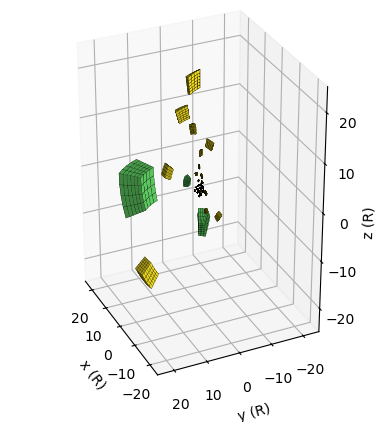

In [364]:
def draw_pc(ax, verts, colors=None, **kwargs):
  verts = verts.reshape((-1,) + verts.shape[-2:])
  print(f"verts shape: {verts.shape}")
  if colors is not None:
    colors = colors.reshape(-1, 3)
    print(f"colors shape: {colors.shape}")
  pc = Poly3DCollection(verts, 
                    facecolors=colors,
                    **kwargs
                    )
  ax.add_collection3d(pc)
  return pc

def draw_blocks(ax, blocks, colors=None, stride=200, **kwargs):
  import matplotlib
  # This is the actual coordinates of the corners in block_cuboid_faces
  # The indices are block ID, nK, nJ, nI, face, corner ID, x/y/z
  if colors is not None:
    assert blocks.shape[0] == colors.shape[0], "Blocks and colors must have the same first dimension"
  blocks = blocks[::stride]
  if colors is not None:
    colors = colors[::stride]

  verts = ds.points[blocks][...,:3]
  print(f"verts shape: {_verts.shape}")

  # verts = verts[:, [0, -1], :, :, :, :]
  # print(verts.shape)
  # verts = verts[:, :, [0, -1], :, :, :]
  # print(verts.shape)
  # verts = verts[:, :, :, [0, -1], :, :]
  # print(verts.shape)
  # verts = verts[:, :, :, :, 0, :]
  # print(verts.shape)
  # verts = verts[:, :, :, :, :, 0:3]
  # print(verts.shape)

  if colors is not None:
    colors = np.repeat(colors, np.prod(verts.shape[1:-2]), axis=0)
    # print(colors.shape)
    colors = colors.reshape(verts.shape[:-2] + (-1,))
    print(colors.shape)

  draw_pc(ax, verts, colors, **kwargs)

  ax.set_xlim(np.min(verts[...,0]), np.max(verts[...,0]))
  ax.set_ylim(np.min(verts[...,1]), np.max(verts[...,1]))
  ax.set_zlim(np.min(verts[...,2]), np.max(verts[...,2]))

  
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
# print(f"verts shape: {_verts.shape}")
# print(f"colors shape: {colors.shape}")
draw_blocks(ax, block_cuboid_face_corners, block_colors, edgecolor='k', linewidth=0.1, shade=True)
# print(f"verts shape: {_verts.shape}")
# print(f"colors shape: {colors.shape}")
ax.set_aspect('equal')
ax.set_xlim(np.min(_verts[...,0]), np.max(_verts[...,0]))
ax.set_ylim(np.min(_verts[...,1]), np.max(_verts[...,1]))
ax.set_zlim(np.min(_verts[...,2]), np.max(_verts[...,2]))
ax.view_init(30, 155)
ax.set_xlabel('x (R)')
ax.set_ylabel('y (R)')
ax.set_zlabel('z (R)')
plt.show()


verts shape: (11988, 4, 4, 6, 6, 4, 3)
verts shape: (6552576, 4, 3)


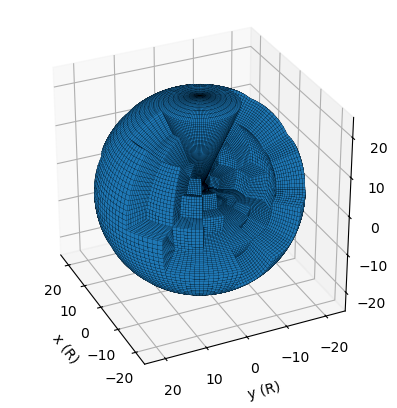

In [29]:
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
draw_blocks(ax, 
            block_cuboid_face_corners[refinement==4], 
            stride=1, edgecolor='k', linewidth=0.1)
# print(f"verts shape: {_verts.shape}")
# print(f"colors shape: {colors.shape}")
ax.set_aspect('equal')
ax.set_xlim(np.min(_verts[...,0]), np.max(_verts[...,0]))
ax.set_ylim(np.min(_verts[...,1]), np.max(_verts[...,1]))
ax.set_zlim(np.min(_verts[...,2]), np.max(_verts[...,2]))
ax.view_init(30, 155)
ax.set_xlabel('x (R)')
ax.set_ylabel('y (R)')
ax.set_zlabel('z (R)')
plt.show()


In [365]:
blocks = {}
# Parent, refinement, bid, pmin, pmax, amin, amax
blocks[0] = np.array([[-1, 0, -1, 0.0, 180.0, -180.0, 0.0], [-1, 0, -1, 0.0, 180.0, 0.0, 180.0]])

for r in range(1,5):
    blocks_l0 = blocks[r-1]
    blocks_l1 = np.ones(np.array([4, 1]) * np.array(blocks_l0.shape)) - 99
    for i0 in range(blocks_l0.shape[0]):
        pmin = blocks_l0[i0, 3]
        pmax = blocks_l0[i0, 4]
        amin = blocks_l0[i0, 5]
        amax = blocks_l0[i0, 6]

        pstep = (pmax - pmin) / 2
        astep = (amax - amin) / 2
        if i0 == 0:
            print(f"Refinement {r}: ", pstep, astep, blocks_l1.shape)

        blocks_l1[4*i0 + 0, :] = [i0, r, -1, pmin + 0 * pstep, pmin + 1 * pstep, amin + 0 * astep, amin + 1 * astep]
        blocks_l1[4*i0 + 1, :] = [i0, r, -1, pmin + 0 * pstep, pmin + 1 * pstep, amin + 1 * astep, amin + 2 * astep]
        blocks_l1[4*i0 + 2, :] = [i0, r, -1, pmin + 1 * pstep, pmin + 2 * pstep, amin + 0 * astep, amin + 1 * astep]
        blocks_l1[4*i0 + 3, :] = [i0, r, -1, pmin + 1 * pstep, pmin + 2 * pstep, amin + 1 * astep, amin + 2 * astep]

    blocks[r] = blocks_l1




# Find blocks inside the cone of a block
def in_cone(block):
    # print(block)


    block_phi = _phi[block_cuboid_corners]
    block_phi_mean = np.mean(block_phi, axis=(1,2,3,4))

    block_theta = _theta[block_cuboid_corners]
    block_theta_mean = np.mean(block_theta, axis=(1,2,3,4))

    theta_ok = np.logical_and(block[3] < block_theta_mean, block_theta_mean < block[4])
    phi_ok = np.logical_and(block[5] < block_phi_mean, block_phi_mean < block[6])

    ok = np.logical_and(theta_ok, phi_ok)
    return ok



Refinement 1:  90.0 90.0 (8, 7)
Refinement 2:  45.0 45.0 (32, 7)
Refinement 3:  22.5 22.5 (128, 7)
Refinement 4:  11.25 11.25 (512, 7)


In [366]:
assert np.sum(np.logical_and(in_cone(blocks[0][0]), in_cone(blocks[0][1]))) == 0
assert np.sum(np.logical_or(in_cone(blocks[0][0]), in_cone(blocks[0][1]))) == refinement.shape[0]
assert np.sum(np.logical_xor(in_cone(blocks[0][0]), in_cone(blocks[0][1]))) == refinement.shape[0]

In [367]:
for j in range(2):
    assert (np.all(np.logical_or.reduce([in_cone(blocks[1][4*j+i]) for i in range(4)]) == in_cone(blocks[0][j])))



verts shape: (11988, 4, 4, 6, 6, 4, 3)
(414, 4, 4, 6, 6, 3)
verts shape: (238464, 4, 3)
colors shape: (238464, 3)


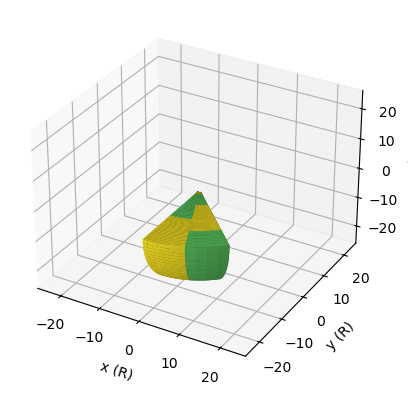

In [370]:
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')

ok = in_cone(blocks[2][12])
draw_blocks(ax, 
            block_cuboid_face_corners[ok], 
            colors=block_colors[ok], 
            stride=1, 
            # edgecolor='k', 
            # linewidth=0.1,
            shade=True)

# ax.set_aspect('equal')
ax.set_xlim(-25, 25)
ax.set_ylim(-25, 25)
ax.set_zlim(-25, 25)
# ax.view_init(60, 0)
ax.set_xlabel('x (R)')
ax.set_ylabel('y (R)')
ax.set_zlabel('z (R)')
plt.show()


In [291]:
print(list(blocks.keys()))

# Find the l0 parents of l1 blocks

_sum = 0
for r in [3]:
    print(f"Refinement {r}, {len(blocks[r])}")
    for i in range(len(blocks[r])):
        incone = in_cone(blocks[r][i])
        # print(f"Refinement {r}, block {i}: {np.sum(incone)}")
        _sum += np.sum(incone)

        is_match = np.logical_and(refinement == r, incone)
        if np.sum(is_match) > 0:
            print(f"Refinement {r}, block {i}: Match {np.sum(is_match)}")

        # blocks[r][i, 2] = 

print(_sum)

[0, 1, 2, 3, 4]
Refinement 3, 128
Refinement 3, block 3: Match 8
Refinement 3, block 6: Match 16
Refinement 3, block 7: Match 8
Refinement 3, block 9: Match 8
Refinement 3, block 11: Match 8
Refinement 3, block 12: Match 14
Refinement 3, block 13: Match 6
Refinement 3, block 14: Match 13
Refinement 3, block 15: Match 5
Refinement 3, block 18: Match 8
Refinement 3, block 24: Match 7
Refinement 3, block 25: Match 6
Refinement 3, block 26: Match 7
Refinement 3, block 27: Match 6
Refinement 3, block 28: Match 5
Refinement 3, block 29: Match 4
Refinement 3, block 30: Match 5
Refinement 3, block 31: Match 2
Refinement 3, block 33: Match 7
Refinement 3, block 35: Match 1
Refinement 3, block 36: Match 11
Refinement 3, block 37: Match 7
Refinement 3, block 38: Match 3
Refinement 3, block 39: Match 4
Refinement 3, block 41: Match 2
Refinement 3, block 44: Match 4
Refinement 3, block 45: Match 1
Refinement 3, block 46: Match 8
Refinement 3, block 47: Match 16
Refinement 3, block 48: Match 6
Refin

32


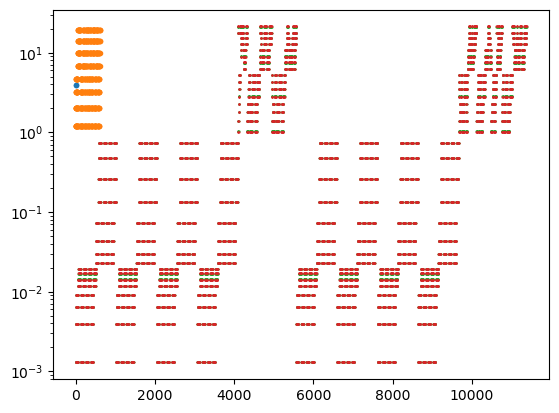

In [334]:
block_r = _r[block_cuboid_corners]
block_r_mean = np.mean(block_r, axis=(1,2,3,4))

r0 = 1
plt.plot((block_r_mean-r0)[refinement==2], '.')
plt.plot((block_r_mean-r0)[refinement==3], '.')
plt.plot((block_r_mean-r0)[refinement==4], '.', markersize=1)

plt.yscale('log')

# print(np.unique(block_r_mean[refinement==2]))
# print(np.unique(block_r_mean[refinement==3]))
# print(np.unique(block_r_mean[refinement==4]))

d=2

s = np.round(np.log10(block_r_mean[refinement==4] - r0), d)
brm4 = 10**s

plt.plot(brm4, '.', markersize=1)

print(len(np.unique(brm4)))



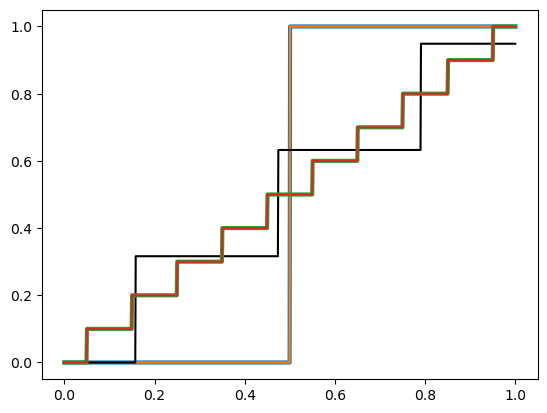

In [360]:

x = np.linspace(0, 1, 1000)
def fround(x, s):
    e=10**s
    return np.round(e*x, 0)/e

i = 0
plt.plot(x, fround(x, i), linewidth=3)
plt.plot(x, np.round(x, i))

plt.plot(x, fround(x, 0.5), color='k')

i=1
plt.plot(x, fround(x, i), linewidth=3)
plt.plot(x, np.round(x, i))



In [349]:
np.round(1.123, 0)

1.0

In [ ]:

def face_list(ds):
    print(ds.corners.shape)
    max_neighbours = 6 if ds.corners.shape[1] == 8 else 4
    neighbours = np.zeros((ds.corners.shape[0], max_neighbours), dtype=int) - 1
    print(f"neighbours.shape = {neighbours.shape}")

    all_faces = defaultdict(lambda: [-1, -1])
    
    for i in range(ds.corners.shape[0]):
        faces = ds.corners[i, face_combinations]
        for face in faces:
            face = tuple(sorted(face))
            if not face in all_faces:
                all_faces[face][0] = i
            else:
                all_faces[face][1] = i

        if i % (len(ds.corners)//10) == 0:
            print(f"{i/len(ds.corners) * 100:.5} %")
    return all_faces

all_faces = face_list(ds)
print(len(all_faces))
all_faces


In [ ]:
def find_neighbours(ds, all_faces):

    neighbours = np.zeros((ds.corners.shape[0], 6), dtype=int) - 1

    for i in range(ds.corners.shape[0]):
        faces = ds.corners[i, face_combinations]
        for j, face in enumerate(faces):
            face = tuple(sorted(face))
            assert face in all_faces

            # The neighbouring faces are in the two columns of all_faces[face]
            if all_faces[face][0] == i:
                neighbours[i, j] = all_faces[face][1]
            elif all_faces[face][1] == i:
                neighbours[i, j] = all_faces[face][0]
            else:
                print(f"face {face} is not shared with {i}")
                raise Exception(f"face {face} is not shared with {i}")

        if i % (len(ds.corners)//100) == 0:
            print(f"{i/len(ds.corners) * 100:.5} %")

    return neighbours

neighbours = find_neighbours(ds, all_faces)
neighbours

In [ ]:
num_neighbours = np.count_nonzero(neighbours != -1, axis=1)
plt.hist(num_neighbours, bins=np.arange(0, 8) - 0.5)
plt.yscale('log')
plt.ylabel('Number of cells')
plt.xlabel('Number of neighbours (max 6)')

In [ ]:
i = 0
candidates = set([i])
for i_j in range(3):
    for candidate in list(candidates):
        for neighbour in neighbours[candidate]:
            if neighbour != -1:
                candidates.add(neighbour)
    print(len(candidates))


In [ ]:

def n_neighbours(ds, neighbours, i, n):
    candidates = set([i])
    for j in range(n):
        for candidate in list(candidates):
            for neighbour in neighbours[candidate]:
                if neighbour != -1:
                    candidates.add(neighbour)
    return candidates

# The quad has six faces, i.e. 6 four-cycles of corners
# How do we even find one of these?

candidates = n_neighbours(ds, neighbours, 0, 3)
candidates

In [ ]:

_counter = 0
fig, axs = plt.subplots(2, 3, figsize=(5, 5))
axs = axs.flatten()

n_b, n_i, n_j, n_k = parse_aux_blocks(ds)
n_b = 5
for i_b in range(n_b):
    color=f"C{i_b%8}"
    for i_k in range(n_k):
        for i_j in range(n_j):
            for i_i in range(n_i):
                corner = ds.corners[i_i + n_i * (i_j + n_j * (i_k + n_k * i_b))]
                # assert i+6*j+4*6*k+4*4*6*block == _counter
                loop = np.append(corner, corner[0])

                loop=np.array(tuple(itertools.combinations(corner, 2))).flatten()

                axs[0].plot(_x[loop], _y[loop], '-', color=color, alpha=0.1)    
                axs[1].plot(_x[loop], _z[loop], '-', color=color, alpha=0.1)
                axs[2].plot(_y[loop], _z[loop], '-', color=color, alpha=0.1)

                axs[3].plot(_r[loop], _theta[loop], '-', color=color, alpha=0.1)    
                axs[4].plot(_r[loop], _phi[loop], '-', color=color, alpha=0.1)
                axs[5].plot(_theta[loop], _phi[loop], '-', color=color, alpha=0.1)

                _counter += 1

for ax, label in zip(axs, ['xy', 'xz', 'yz', 'rθ', 'rφ', 'θφ']):
    ax.set_title(label)
print(_counter)

In [ ]:
print(f"{ds.points.shape=}")
print(f"{ds.corners.shape=}")
assert ds.points.shape[0] == np.max(ds.corners) + 1

print(f"{ds.corners.shape[0] /  (n_i * n_j * n_k) = }")
print(f"{ds.corners.shape[0] %  (n_i * n_j * n_k) = }")
assert ds.corners.shape[0] %    (n_i * n_j * n_k) == 0
print(f"{ds.corners.shape[0] // (n_i * n_j * n_k) = }")


```fortran
             do iBlock = 1,nBlock
                if(iTypeAdvance_B(iBlock) == SkippedBlock_) CYCLE
                ! Write point values
                call fill_node_xyz
                do k=1,nK+1; do j=1,nJ+1; do i=1,nI+1
                   if(IsNodeUnique_NB(i,j,k,iBlock))then
                      write(UnitTmp_,fmt="(50(ES14.6))") &
                           NodeXYZ_DN(1:3,i,j,k),       &
                           PlotVarNodes_VNB(1:nPlotVar,i,j,k,iBlock)
                   end if
                end do; end do; end do
                ! Write point connectivity
                do k=1,nK; do j=1,nJ; do i=1,nI
                   write(UnitTmp2_,'(8i11)') &
                        iNodeGlobal_NB(i  ,j  ,k  ,iBlock), &
                        iNodeGlobal_NB(i+1,j  ,k  ,iBlock), &
                        iNodeGlobal_NB(i+1,j+1,k  ,iBlock), &
                        iNodeGlobal_NB(i  ,j+1,k  ,iBlock), &
                        iNodeGlobal_NB(i  ,j  ,k+1,iBlock), &
                        iNodeGlobal_NB(i+1,j  ,k+1,iBlock), &
                        iNodeGlobal_NB(i+1,j+1,k+1,iBlock), &
                        iNodeGlobal_NB(i  ,j+1,k+1,iBlock)
                end do; end do; end do
             end do
          end if
       end if
```

In [ ]:
BLOCK_SHAPE=(n_i, n_j, n_k)
def leaf_blocks(ds, shape=BLOCK_SHAPE):
    """
    Returns a list of leaf blocks, i.e. the blocks that are not further subdivided.
    These are actually stored in the dataset as a 1D array, so we just need to reshape it.
    The first id is block id and the second id is the corner id.
    """
    num_blocks = ds.corners.shape[0] // np.prod(shape)
    _leaf_blocks = np.zeros((num_blocks, np.prod(shape)), dtype=int)
    for block in range(num_blocks):
        _leaf_blocks[block] = np.arange(np.prod(shape)) + block * np.prod(shape)

    return _leaf_blocks
    
lb = leaf_blocks(ds)
lb.shape
lb[0]

In [ ]:
# The blocks are stored in the dataset as a 1D array, so we just need to reshape it.
lb = lb.reshape((lb.shape[0],) + BLOCK_SHAPE[::-1])

_ids = lb[1, 0, 0, :]
_ids

In [ ]:
# Points are stored first (as points), their id is their index in the points array
# idnex with pid

# Cuboid corners are points.

# Cuboids are stored second, their id their index in the cuboids array. Cuboid are defined by their corners.
# The corners of each cuboid is represented by a list of point ids.
# index with cid

# Leaf blocks are not stored, but can be inferred from the cuboids array, as each block comprses 6x4xr4 cuboids.
# They are simply stored consequetively in the cuboids array.
# A block neibgbours another block if all their cuboids on a cuboid face neighbour 
# all the cuboids on the other block's face.
# index with bid

def block_face_cubes(block, xyz=0, i=0):
    
    if xyz == 0:
        face_ids = block[i, :, :]
    elif xyz == 1:
        face_ids = block[:, i, :]
    elif xyz == 2:
        face_ids = block[:, :, i]
    else:
        raise ValueError(f"{xyz=}")
    
    return face_ids
    
bfc0 = block_face_cubes(lb[0], 0, 1)
bfc1 = block_face_cubes(lb[1], 0, 0)




In [ ]:
# For a block to neighbour another block
# Too slow!
n_b, n_i, n_j, n_k = parse_aux_blocks(ds)
print(f"{n_b=}, {n_i=}, {n_j=}, {n_k=}")
block_neighbours = np.eye(n_b, dtype=int) * 0
for i in range(n_b):
    cubes_in_block_i = list(lb[i, :, :, :].flatten())
    neighbours_of_block_i = set(list(neighbours[cubes_in_block_i].flatten())) 
    if -1 in neighbours_of_block_i:
        neighbours_of_block_i.remove(-1)
    # print(f"{len(cubes_in_block_i)=}")
    # print(f"{len(neighbours_of_block_i)=}")


    for i_j in range(n_b):

        cubes_in_block_j = list(lb[i_j, :, :, :].flatten())

        # print(f"{cubes_in_block_j=}")
        # print(f"{neighbours_of_block_i=}")


        neighbouring_cubes_ij = neighbours_of_block_i.intersection(cubes_in_block_j)
        block_neighbours[i, i_j] = len(neighbouring_cubes_ij)
        if len(neighbouring_cubes_ij) > 0:
            print(f"{i=}, {i_j=}, {len(neighbouring_cubes_ij)=}")
            # print(f"{neighbouring_cubes_ij=}")

        # break


In [ ]:

print(i, i_j)
block_neighbours
plt.spy(block_neighbours)

In [ ]:
lb.shape
i = 0
bf_i = block_face_cubes(lb[i], 0, 0) 
bf_i
all_block_faces = defaultdict(lambda: [-1, -1])
block_neighbours = np.zeros((n_b, 6), dtype=int)-1
for i_b in range(n_b):
    _face_id = 0
    for xyz in range(3):
        for i in [0, -1]:
            sorted_face_cubes = tuple(np.sort(block_face_cubes(lb[i_b], xyz, i).flatten()))
            print(f"{sorted_face_cubes=}")

            if not sorted_face_cubes in all_block_faces:
                all_block_faces[sorted_face_cubes][0] = i_b
            else:
                all_block_faces[sorted_face_cubes][1] = i_b
                print(f"Found match {all_block_faces[sorted_face_cubes][0]} {all_block_faces[sorted_face_cubes][1]}")


            _face_id += 1

all_block_faces


In [ ]:


n1 = set(list(neighbours[bfc1].flatten()))

neighbours_of_block_i.intersection(n1)

In [ ]:
# Draw a cube


In [ ]:

# Could just check what block it is inside, and then find the value inside the block.



In [ ]:

lb.shape
_ids = lb[1, 0, 0, :]

fig, axs = plt.subplots(2, 3, figsize=(5, 5))
axs = axs.flatten()
axs[0].plot(
    _x[ds.corners[_ids]],
    _y[ds.corners[_ids]], 'o-')
axs[1].plot(
    _x[ds.corners[_ids]],
    _z[ds.corners[_ids]], 'o-')
axs[2].plot(
    _y[ds.corners[_ids]],
    _z[ds.corners[_ids]], 'o-')
axs[3].plot(
    _r[ds.corners[_ids]],
    _theta[ds.corners[_ids]], 'o-')

axs[4].plot(
    _r[ds.corners[_ids]],
    _phi[ds.corners[_ids]], 'o-')

axs[5].plot(
    _theta[ds.corners[_ids]],
    _phi[ds.corners[_ids]], 'o-')

_r[ds.corners[_ids]]

In [ ]:
# and plot everything
ax = plt.figure().add_subplot(projection='3d')

for i in range(0,6):
    X, Y, Z = np.meshgrid(
        [np.min(_x[ds.corners[i]]), np.max(_x[ds.corners[i]])],
        [np.min(_y[ds.corners[i]]), np.max(_y[ds.corners[i]])],
        [np.min(_z[ds.corners[i]]), np.max(_z[ds.corners[i]])]
    )
    ax.voxels(X, Y, Z, filled=np.atleast_3d(1), alpha=0.3)

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.colors


def midpoints(x):
    sl = ()
    for i in range(x.ndim):
        x = (x[sl + np.index_exp[:-1]] + x[sl + np.index_exp[1:]]) / 2.0
        sl += np.index_exp[:]
    return x

# prepare some coordinates, and attach rgb values to each
r, theta, z = np.mgrid[0:1:3j, 0:np.pi*2:10j, -0.5:0.5:11j]
x = r*np.cos(theta)
y = r*np.sin(theta)

rc, thetac, zc = midpoints(r), midpoints(theta), midpoints(z)

# define a wobbly torus about [0.7, *, 0]
sphere = np.ones([i-1 for i in x.shape])

# combine the color components
hsv = np.zeros(sphere.shape + (3,))
hsv[..., 0] = thetac / (np.pi*2)
hsv[..., 1] = rc
hsv[..., 2] = zc + 0.5
colors = matplotlib.colors.hsv_to_rgb(hsv)

# and plot everything
ax = plt.figure().add_subplot(projection='3d')
ax.voxels(x, y, z, sphere,
          facecolors=colors,
          edgecolors=np.clip(2*colors - 0.5, 0, 1),  # brighter
          linewidth=0.5)

plt.show()

In [ ]:

theta = np.arctan2(_z, np.sqrt(_x**2 + _y**2))
plt.hist(theta)
plt.figure()
plt.plot(theta[ds.corners]/np.pi, '.')
plt.grid()

phi = np.arctan2(_y, _x)
# plt.hist(theta)
# plt.figure()
# plt.plot(np.log2(2/(theta[ds.corners]/np.pi)), '.')
# plt.grid()


In [ ]:
delta_phi = np.max(phi[ds.corners], axis=1) - np.min(phi[ds.corners], axis=1)
plt.plot(delta_phi/np.pi, '.')
delta_phi[delta_phi > np.pi] = 2*np.pi - delta_phi[delta_phi > np.pi]
print(np.max(delta_phi)/np.pi)
plt.plot(delta_phi/np.pi, '.')


plt.grid()

plt.figure()
plt.plot(delta_phi/np.pi, '.')
plt.grid()





In [ ]:
print(f"{len(phi)=}")
print(f"{np.max(ds.corners)}")
print(f"{len}")

In [ ]:
_x = ds('X [R]')
_y = ds('Y [R]')
_z = ds('Z [R]')
theta = np.arctan2(_z, np.sqrt(_x**2 + _y**2))
plt.hist(theta)
plt.figure()
plt.plot(np.log2(2/(theta[ds.corners]/np.pi)), '.')
plt.grid()


In [ ]:
delta_theta = np.max(theta[ds.corners], axis=1) - np.min(theta[ds.corners], axis=1)
plt.plot(delta_theta/np.pi, '.')
delta_theta[delta_theta > np.pi] = 2*np.pi - delta_theta[delta_theta > np.pi]
print(np.max(delta_theta)/np.pi)
plt.plot(delta_theta/np.pi, '.')


plt.grid()

plt.figure()
plt.semilogy(np.pi/delta_theta, '.',)
plt.grid()


In [ ]:
poweroftwo = np.log2(1/(delta_theta/np.pi))
poweroftwo = np.round(poweroftwo).astype
plt.plot(poweroftwo, '.')

In [ ]:
# If the larger cells are still in there then there are corners that are shared between more than 8 cells
uses = np.zeros(np.max(ds.corners)+1)
for c in ds.corners.flatten():
    uses[c] += 1
assert np.max(uses) == 8
plt.plot(uses, '.')
